# Constrained sampling on real data: anchored Langevin with a **state-dependent** $J$

This is `Constrained_Sampling_ANDS_ball_constrained.ipynb` carried over from the synthetic
3-dimensional target to two real binary-classification posteriors — **Titanic** and the
**MAGIC Gamma Telescope** — with the same figure set: $W_1$ per coordinate, 2-d contours with
the constraint drawn, a sweep over the skew strength, and a fixed-physical-time stepsize
control.

Three things change on real data, and the third is the one worth the notebook.

1. **The target is a Gibbs posterior, non-differentiable twice over.** For labels
   $y_i\in\{-1,+1\}$ and standardised features $\phi_i$, write $\psi_i=y_i\phi_i$ and

   $$U(w)\;=\;\tau\,\frac1n\sum_{i=1}^n\max\!\bigl(0,\,1-w^{\!\top}\psi_i\bigr)\;+\;\lambda\lVert w\rVert_1,
   \qquad \pi(w)\;\propto\;e^{-U(w)}\,\mathbf 1_K(w),$$

   on the ball $K=\{\lVert w\rVert_2\le R\}$. The hinge kinks at every active margin and the
   $\ell_1$ prior kinks on every coordinate axis. $U$ is only ever **evaluated**, never
   differentiated — which is the whole premise of the anchored scheme.

2. **There is no analytic reference.** The synthetic notebook could draw exact samples by
   rejection. Here the reference is a long random-walk Metropolis chain run against the
   *exact* non-smooth $U$ with proposals rejected outside $K$, which is reversible for
   $\pi\mathbf 1_K$ with no projection bias. A second, independent reference chain sets the
   floor: the $W_1$ below which two samples of this size are indistinguishable.

3. **$d$ is 10 and 11, not 3 — and that turns the correction term on.** In the original
   notebook the axial field happened to be divergence-free, so the correction could be
   dropped. In $d>3$ it cannot. That is Experiment 3.

## What the anchored dynamics needs from $J$

For constant skew $J$ the extra stationary flux is $J\nabla\varphi$ with $\varphi=e^{-U_0}$, and
$\nabla\!\cdot(J\nabla\varphi)=0$ follows from antisymmetry alone. Once $J$ varies with $x$ that
argument fails; the correct divergence-free flux is $\mathcal F_i=\sum_j\partial_j(J_{ij}\varphi)$,
whose divergence vanishes because $J_{ij}\varphi$ is antisymmetric in $(i,j)$ while
$\partial_i\partial_j$ is symmetric. Dividing by $\pi$ gives the **anchored, state-dependent-$J$
dynamics**

$$\boxed{\;dX_t=e^{\Delta(X_t)}\Bigl[-\bigl(I+J(X_t)\bigr)\nabla U_0(X_t)+\nabla\!\cdot J(X_t)\Bigr]dt
\;+\;\sqrt2\,e^{\Delta(X_t)/2}\,dW_t\;}$$

with $(\nabla\!\cdot J)_i=\sum_j\partial_j J_{ij}$ and $\Delta=U-U_0$.

Sampling on $K$ by projection adds a **second, independent** condition: the skew drift must be
tangential to the wall,

$$J(x)\,\nu(x)=0\quad\text{for }x\in\partial K,\qquad\nu(x)=x/\lVert x\rVert,$$

or the skew term pushes probability into the boundary, the projection absorbs it, and the
stationary law is distorted by an amount no stepsize refinement removes.

### The three fields, generalised to $d$ dimensions

The original notebook's axial field $J_s(x)w=s\,(x\times w)$ is a cross product and exists only
in $d=3$. Its $d$-dimensional replacement, for a fixed antisymmetric $A$ (the tridiagonal skew,
normalised to unit spectral norm), is

$$J_s(x)\;=\;\frac{s}{R^2}\Bigl[\lVert x\rVert^2A\;+\;x\,(Ax)^{\!\top}-\,(Ax)\,x^{\!\top}\Bigr].$$

It is antisymmetric for every $x$; it annihilates $x$ **identically**, $J_s(x)x=0$, so
$J_s\nu=0$ on $\partial K$ by construction; it is polynomial, so there is no singularity at the
origin; and the $1/R^2$ makes $\lVert J_s\rVert$ on the wall comparable to $\lVert J_a\rVert$ at
the same $s$. Its divergence is available in closed form:

$$(\nabla\!\cdot J_s)(x)\;=\;-\frac{s}{R^2}\,(d-2)\,Ax .$$

| | $J(x)$ | $\nabla\!\cdot J$ | $J(x)\nu(x)$ on $\partial K$ |
|---|---|---|---|
| `none` | $0$ | $0$ | $0$ |
| `const` | $s\,A$ (constant) | $0$ | $s\,A\nu\neq0$ — **violates the boundary condition** |
| `axial` | $\tfrac{s}{R^2}\bigl[r^2A+x(Ax)^{\!\top}-(Ax)x^{\!\top}\bigr]$ | $-\tfrac{s}{R^2}(d-2)Ax\neq0$ — **correction is mandatory** | $0$ — satisfied identically |

Note the $(d-2)$: the correction vanishes at $d=2$, and at $d=3$ it is small, which is why the
original notebook could get away with a divergence-free 3-d field. At $d=10$ and $d=11$ it is the
same order as the drift itself. Both claims are checked numerically below rather than taken on
faith.

In [1]:
%matplotlib inline
import os, sys, time, json
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import torch
torch.set_default_dtype(torch.float64)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

from ands import data as D, diagnostics as G, experiments as E, plots as P, skew as SK

CFG = E.CONFIG
print(json.dumps({k: v for k, v in CFG.items()}, indent=2))

{
  "tau": 100.0,
  "lam": 1.0,
  "delta": 0.02,
  "N": 2000,
  "n_steps": 2000,
  "eta": 0.0003,
  "s_main": 4.0,
  "sweep": [
    0.0,
    1.0,
    2.0,
    4.0,
    8.0
  ],
  "ref_chains": 2500,
  "ref_steps": 6000,
  "track_every": 25,
  "seed": 106
}


## The two datasets

In [2]:
DS = {"titanic": D.load_titanic(), "magic": D.load_magic(2000)}
rows = []
for key, ds in DS.items():
    rows.append({"dataset": key, "title": ds.title, "n": ds.n, "d": ds.d,
                 "P(y=+1)": round(float((ds.y > 0).mean()), 3),
                 "R": E.DATASETS[key]["R"],
                 "sha256[:16]": D.file_digest(key)})
display(pd.DataFrame(rows).set_index("dataset"))
for key, ds in DS.items():
    print("{:8s} {}".format(key, ds.feature_names))

,title,n,d,P(y=+1),R,sha256[:16]
dataset,,,,,,
titanic,Titanic (survival),891,10,0.384,1.4,81787d320d7f7b03
magic,MAGIC Gamma Telescope (gamma vs hadron),2000,11,0.648,1.9,e9314b7ebd4b4b59


titanic  ['intercept', 'pclass_1', 'pclass_2', 'female', 'age', 'sibsp', 'parch', 'log_fare', 'emb_C', 'emb_Q']
magic    ['intercept', 'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist']


### The anchor

The hinge term is an **average**, not a sum. That matters: the smoothing gap of the anchor is
then $O(\tau\delta)$ regardless of the sample size $n$, so $e^{\Delta}=e^{U-U_0}$ stays a healthy
$O(1)$ time change. With a sum, the gap would grow like $n\tau\delta$ and $e^{\Delta}$ would
underflow to zero on any real dataset — the anchored scheme would silently stop moving.

Both smoothings dominate what they replace ($\sqrt{z^2+\delta^2}\ge|z|$), so $U_0\ge U$ and
$e^{\Delta}\in(0,1]$.

In [3]:
rows = []
for key in DS:
    tgt = E.build_target(key)
    g = torch.Generator().manual_seed(0)
    w = tgt.project(torch.randn(4000, tgt.d, generator=g) * (tgt.R / np.sqrt(tgt.d)) * 2)
    Delta = tgt.anchor_gap(w)
    bound = tgt.tau * tgt.delta / 2 + tgt.lam * tgt.d * tgt.delta
    rows.append({"dataset": key,
                 "U0 >= U everywhere": bool((tgt.U0(w) >= tgt.U(w) - 1e-12).all()),
                 "min Delta": round(float(Delta.min()), 4),
                 "worst-case bound": round(-bound, 4),
                 "min e^Delta": round(float(torch.exp(Delta).min()), 4),
                 "mean |grad U0|": round(float(tgt.grad_U0(w).norm(dim=1).mean()), 2)})
display(pd.DataFrame(rows).set_index("dataset"))

,U0 >= U everywhere,min Delta,worst-case bound,min e^Delta,mean |grad U0|
dataset,,,,,
titanic,True,-0.1441,-1.20,0.8658,69.31
magic,True,-0.0879,-1.22,0.9159,66.64


## Check 1 — the two conditions, numerically

`autograd_divergence` differentiates $J_{ij}(x)$ entry by entry and contracts, with no knowledge
of the closed forms. Agreement to $10^{-15}$ is the statement that
$\nabla\!\cdot J_s=-\frac{s}{R^2}(d-2)Ax$ is right.

In [4]:
S_MAIN = CFG["s_main"]
rows = []
for key in DS:
    tgt, d, R = E.build_target(key), DS[key].d, E.DATASETS[key]["R"]
    g = torch.Generator().manual_seed(11)
    x = torch.randn(300, d, generator=g)
    x_wall = R * x / x.norm(dim=1, keepdim=True)          # points on dK
    for kind in ("const", "axial"):
        f = SK.build_skew(kind, d, S_MAIN, radius=R)
        div_auto = SK.autograd_divergence(f, x[:8])
        rows.append({
            "dataset": key, "field": kind, "d": d,
            "max |J + J^T|": "{:.1e}".format(SK.antisymmetry_error(f, x[:8])),
            "|div_autograd - div_closed|": "{:.1e}".format(
                float((div_auto - f.divergence(x[:8])).abs().max())),
            "mean ||div J|| on dK": round(float(f.divergence(x_wall).norm(dim=1).mean()), 3),
            "mean ||J(x) nu|| on dK": "{:.2e}".format(
                float(SK.boundary_flux(f, x_wall).mean())),
            "mean ||J||_2 on dK": round(SK.mean_operator_norm(f, x_wall), 3)})
display(pd.DataFrame(rows).set_index(["dataset", "field"]))

d max |J + J^T| |div_autograd - div_closed|  \
dataset field                                                 
titanic const  10       0.0e+00                     0.0e+00   
        axial  10       1.8e-15                     3.6e-15   
magic   const  11       0.0e+00                     0.0e+00   
        axial  11       8.9e-16                     3.6e-15   

               mean ||div J|| on dK mean ||J(x) nu|| on dK  mean ||J||_2 on dK  
dataset field                                                                   
titanic const                 0.000               2.76e+00               4.000  
        axial                15.757               3.99e-16               3.823  
magic   const                 0.000               2.75e+00               4.000  
        axial                13.005               4.05e-16               3.857

## Check 2 — the exact reference

Two independent random-walk Metropolis runs against the exact $U$, proposals rejected outside
$K$. The acceptance rate is tuned to the Roberts–Gelman–Gilks optimum by a pilot covariance. The
`W1 floor` is the mean $W_1$ between equally sized draws from the two runs: a method at the floor
is statistically indistinguishable from the truth at this sample size, and nothing below it means
anything.

In [5]:
REF = {}
for key in DS:
    REF[key] = E.reference(key)
    r = REF[key]
    print("         classification accuracy at the posterior mean: {:.3f}".format(
        r["target"].accuracy(r["ref"])))

titanic  reference: 2500 samples, RWM acceptance 0.240, boundary mass 0.0056, W1 floor 0.0063
         classification accuracy at the posterior mean: 0.788
magic    reference: 2500 samples, RWM acceptance 0.234, boundary mass 0.0032, W1 floor 0.0084
         classification accuracy at the posterior mean: 0.796


## Experiment 1 — $J=0$ vs constant $J_a$ vs state-dependent $J_s$

Same walkers, same seed, same stepsize; the only difference is the skew field. The state-dependent
run carries its $\nabla\!\cdot J$ correction.

In [6]:
METHODS = [("none", 0.0, False), ("const", S_MAIN, False), ("axial", S_MAIN, False)]
EXP1 = {}
for key in DS:
    tgt, ref = REF[key]["target"], REF[key]["ref"]
    EXP1[key] = {}
    for kind, s, drop in METHODS:
        lab = E.METHOD_LABEL[kind]
        t0 = time.time()
        EXP1[key][lab] = E.chain(key, kind, s, ref=ref, drop_correction=drop)
        print("{:8s} {:28s} {:5.0f}s".format(key, lab.replace("$", ""), time.time() - t0))

    tab = []
    for lab, r in EXP1[key].items():
        sc = E.score(ref, r["x"], tgt.R)
        tab.append({"method": lab.replace("$", ""),
                    "mean W1": round(sc["W1_mean"], 4),
                    "worst-coordinate W1": round(float(sc["W1"].max()), 4),
                    "max KS": round(sc["maxKS"], 4),
                    "mass near dK": "{:.2%}".format(sc["boundary"])})
    tab.append({"method": "reference (truth)", "mean W1": round(REF[key]["floor"].mean(), 4),
                "worst-coordinate W1": round(float(REF[key]["floor"].max()), 4), "max KS": 0.0,
                "mass near dK": "{:.2%}".format(G.boundary_mass(ref, tgt.R))})
    print("\n== {} ==".format(DS[key].title))
    display(pd.DataFrame(tab).set_index("method"))

titanic  J = 0                            0s
titanic  constant J_a                     0s
titanic  state-dependent J_s              0s



== Titanic (survival) ==


,mean W1,worst-coordinate W1,max KS,mass near dK
method,,,,
J = 0,0.0061,0.0086,0.0372,6.80%
constant J_a,0.0387,0.0911,0.2180,16.50%
state-dependent J_s,0.0065,0.0101,0.0381,7.20%
reference (truth),0.0063,0.0096,0.0000,0.56%


magic    J = 0                            0s
magic    constant J_a                     0s
magic    state-dependent J_s              0s



== MAGIC Gamma Telescope (gamma vs hadron) ==


,mean W1,worst-coordinate W1,max KS,mass near dK
method,,,,
J = 0,0.0096,0.0160,0.0405,3.75%
constant J_a,0.0409,0.1265,0.1927,10.30%
state-dependent J_s,0.0092,0.0153,0.0453,3.50%
reference (truth),0.0084,0.0148,0.0000,0.32%


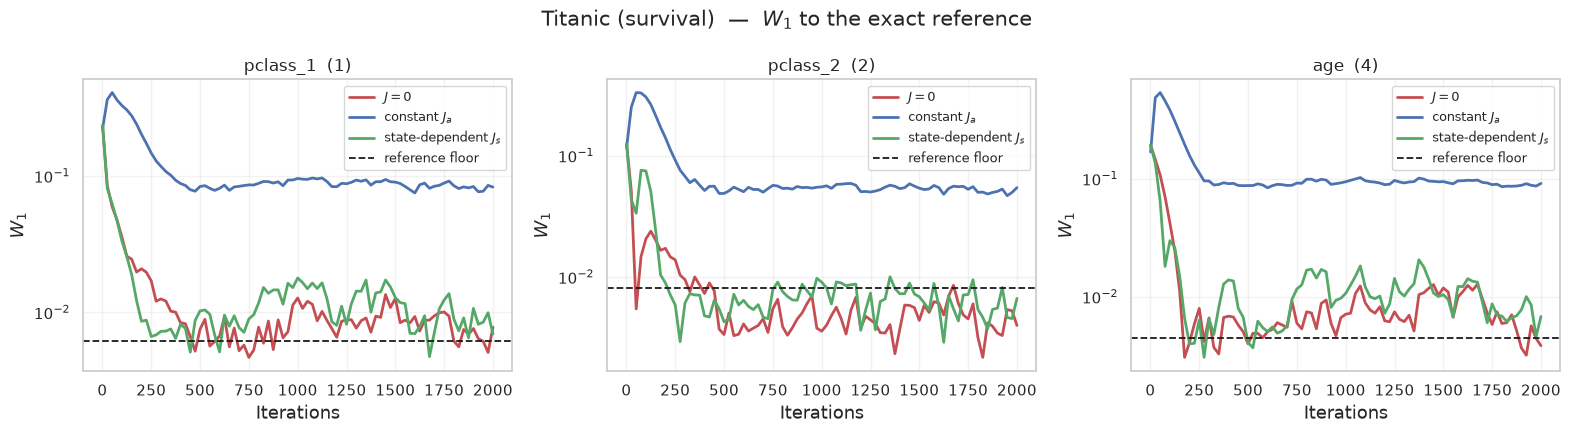

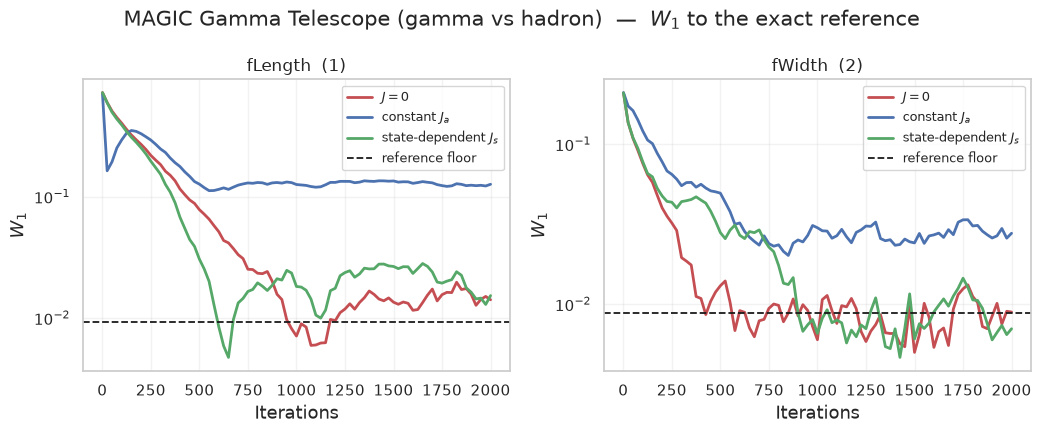

In [7]:
for key in DS:
    worst = int(np.argmax(E.score(REF[key]["ref"], EXP1[key][E.METHOD_LABEL["const"]]["x"],
                                  REF[key]["target"].R)["W1"]))
    coords = sorted({1, 2, worst})[:3]
    P.w1_traces(EXP1[key], REF[key]["floor"], DS[key].feature_names,
                DS[key].title + r"  —  $W_1$ to the exact reference",
                "w1_{}".format(key), coords=coords)
    plt.show()

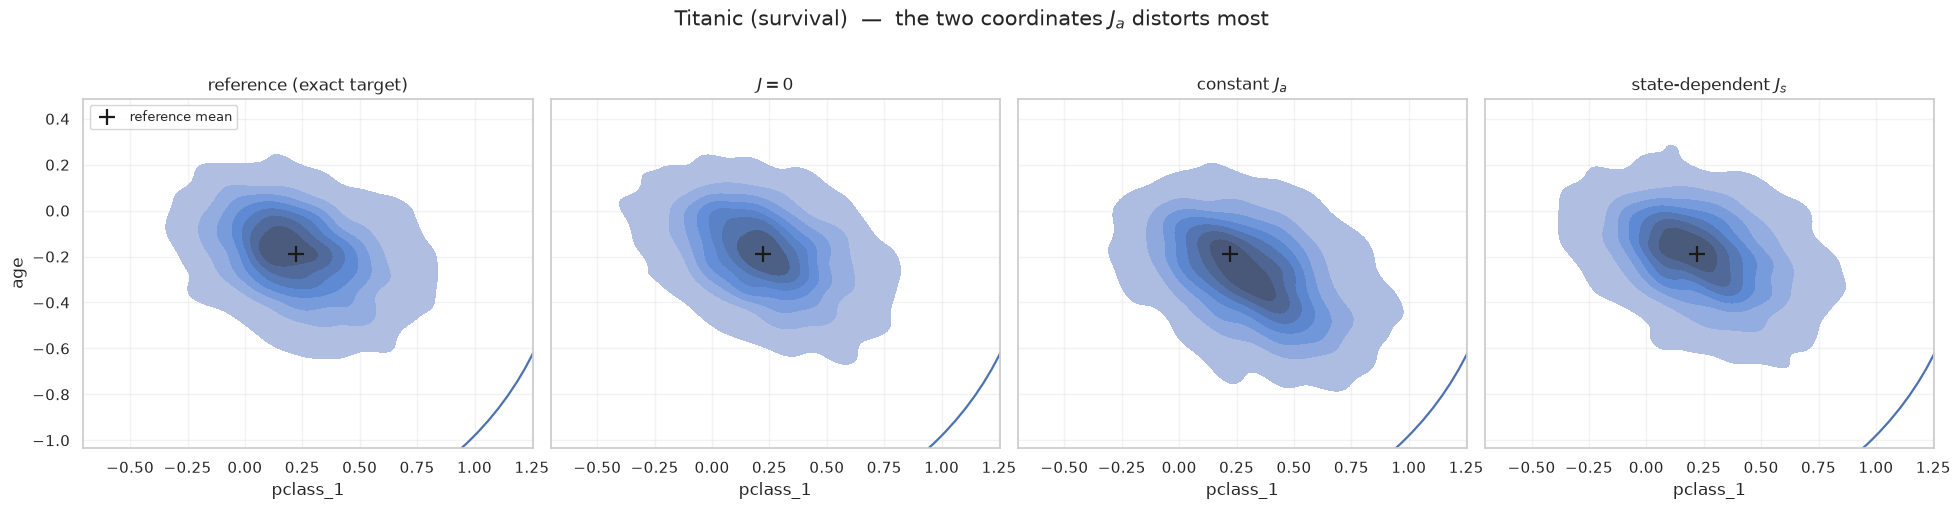

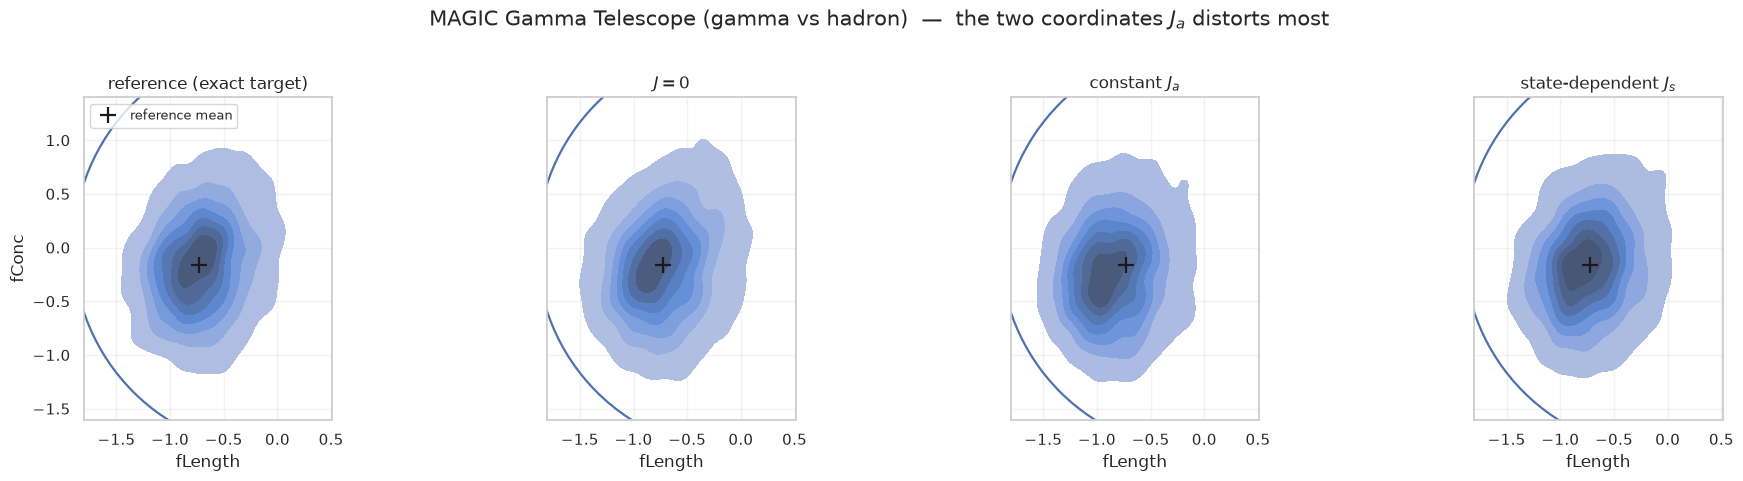

In [8]:
# the two coordinates the inadmissible field damages most
for key in DS:
    err = E.score(REF[key]["ref"], EXP1[key][E.METHOD_LABEL["const"]]["x"],
                  REF[key]["target"].R)["W1"]
    dims = tuple(sorted(np.argsort(err)[-2:]))
    P.density_panels(REF[key]["ref"], EXP1[key], E.DATASETS[key]["R"],
                     DS[key].title + "  —  the two coordinates $J_a$ distorts most",
                     "density_{}".format(key), dims=dims,
                     feature_names=DS[key].feature_names)
    plt.show()

The 2-d slices understate the problem, because in $d=10$ and $d=11$ the constraint binds
*radially* — in all coordinates at once — and no pair of them shows the wall. The law of
$\lVert w\rVert$ is where it becomes visible: projection puts an **atom** exactly at
$\lVert w\rVert = R$ that the continuous target does not have, and the inadmissible field
feeds it.

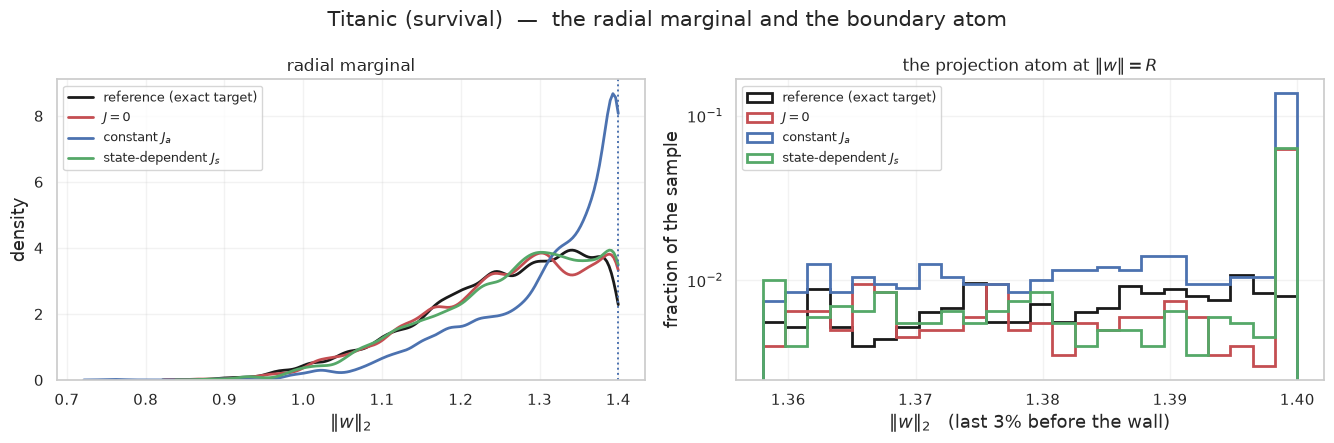

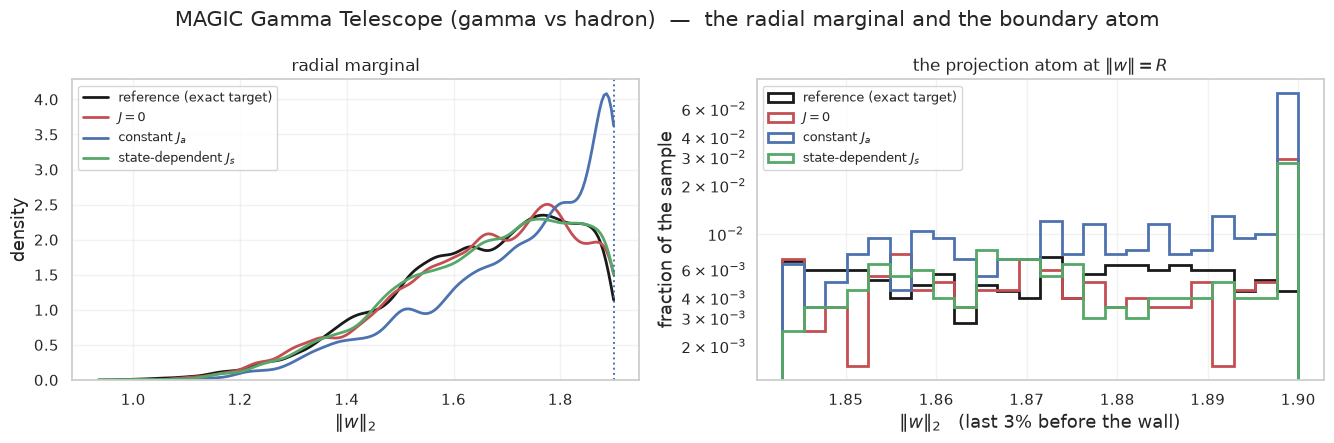

In [9]:
for key in DS:
    P.radius_panels(REF[key]["ref"], EXP1[key], E.DATASETS[key]["R"],
                    DS[key].title + r"  —  the radial marginal and the boundary atom",
                    "radius_{}".format(key))
    plt.show()

## Experiment 2 — sweep over the skew strength

If the boundary condition is what matters, the penalty should grow with how hard the inadmissible
field pushes, and the admissible one should be flat.

In [10]:
SWEEP = {}
for key in DS:
    tgt, ref = REF[key]["target"], REF[key]["ref"]
    SWEEP[key] = {}
    for kind in ("const", "axial"):
        lab = E.METHOD_LABEL[kind]
        ss, w1, bd, ks = [], [], [], []
        for s in CFG["sweep"]:
            r = E.chain(key, "none" if s == 0 else kind, s, ref=ref)
            sc = E.score(ref, r["x"], tgt.R)
            ss.append(s); w1.append(sc["W1_mean"]); bd.append(sc["boundary"]); ks.append(sc["maxKS"])
        SWEEP[key][lab] = {"s": ss, "W1_mean": w1, "boundary": bd, "maxKS": ks}

    tab = {}
    for lab, r in SWEEP[key].items():
        tab[lab.replace("$", "") + " : mean W1"] = [round(v, 4) for v in r["W1_mean"]]
        tab[lab.replace("$", "") + " : mass near dK"] = ["{:.2%}".format(v) for v in r["boundary"]]
    print("\n== {} ==".format(DS[key].title))
    display(pd.DataFrame(tab, index=["s = {:g}".format(s) for s in CFG["sweep"]]).T)


== Titanic (survival) ==


,s = 0,s = 1,s = 2,s = 4,s = 8
constant J_a : mean W1,0.0061,0.0198,0.0303,0.0387,0.0475
constant J_a : mass near dK,6.80%,7.85%,11.15%,16.50%,27.15%
state-dependent J_s : mean W1,0.0061,0.0059,0.0055,0.0065,0.0131
state-dependent J_s : mass near dK,6.80%,6.75%,6.45%,7.20%,8.10%



== MAGIC Gamma Telescope (gamma vs hadron) ==


,s = 0,s = 1,s = 2,s = 4,s = 8
constant J_a : mean W1,0.0096,0.0202,0.0291,0.0409,0.0531
constant J_a : mass near dK,3.75%,4.75%,5.75%,10.30%,16.55%
state-dependent J_s : mean W1,0.0096,0.0097,0.009,0.0092,0.014
state-dependent J_s : mass near dK,3.75%,3.75%,3.40%,3.50%,4.20%


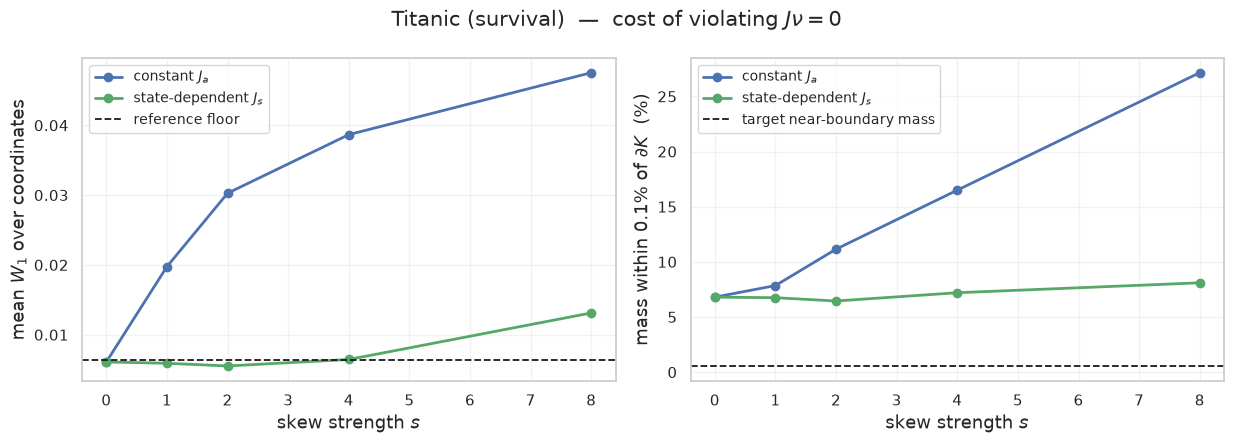

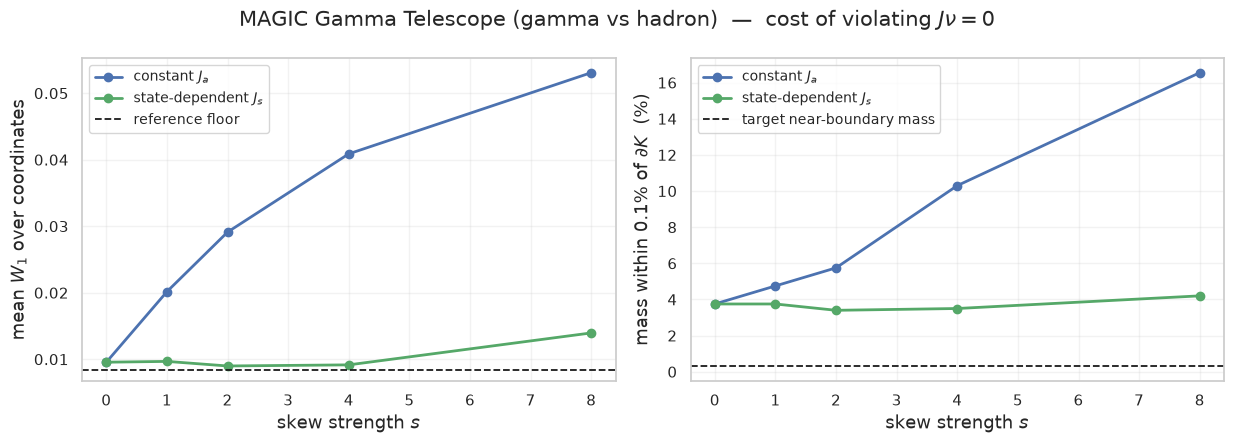

In [11]:
for key in DS:
    P.sweep_panels(SWEEP[key], REF[key]["floor"].mean(),
                   G.boundary_mass(REF[key]["ref"], E.DATASETS[key]["R"]),
                   DS[key].title + "  —  cost of violating $J\\nu = 0$",
                   "sweep_{}".format(key))
    plt.show()

## Experiment 3 — the correction term is not optional

This is the experiment the 3-dimensional notebook could not run. There $\nabla\!\cdot J_s$ was
exactly zero, so the state-dependent update coincided with the constant-$J$ one and the theory's
correction term was a formality. At $d=10$ and $d=11$ it is not: dropping
$+\,e^{\Delta}\nabla\!\cdot J$ leaves a field that is antisymmetric and tangential — it passes both
checks above — and still samples the wrong distribution, because the flux it generates is no longer
divergence-free.

In [12]:
ABLATION = {}
for key in DS:
    tgt, ref = REF[key]["target"], REF[key]["ref"]
    ABLATION[key] = {}
    for drop, kind in [(False, "axial"), (True, "axial_nocorr")]:
        lab = E.METHOD_LABEL[kind]
        ss, w1, bd = [], [], []
        for s in CFG["sweep"]:
            r = E.chain(key, "none" if s == 0 else "axial", s, ref=ref,
                        drop_correction=drop and s > 0)
            sc = E.score(ref, r["x"], tgt.R)
            ss.append(s); w1.append(sc["W1_mean"]); bd.append(sc["boundary"])
        ABLATION[key][lab] = {"s": ss, "W1_mean": w1, "boundary": bd}

    tab = {lab.replace("$", ""): [round(v, 4) for v in r["W1_mean"]]
           for lab, r in ABLATION[key].items()}
    tab["reference floor"] = [round(REF[key]["floor"].mean(), 4)] * len(CFG["sweep"])
    print("\n== {} ==  mean W1".format(DS[key].title))
    display(pd.DataFrame(tab, index=["s = {:g}".format(s) for s in CFG["sweep"]]).T)


== Titanic (survival) ==  mean W1


,s = 0,s = 1,s = 2,s = 4,s = 8
state-dependent J_s,0.0061,0.0059,0.0055,0.0065,0.0131
"J_s, correction dropped",0.0061,0.0284,0.0490,0.0724,0.1014
reference floor,0.0063,0.0063,0.0063,0.0063,0.0063



== MAGIC Gamma Telescope (gamma vs hadron) ==  mean W1


,s = 0,s = 1,s = 2,s = 4,s = 8
state-dependent J_s,0.0096,0.0097,0.0090,0.0092,0.0140
"J_s, correction dropped",0.0096,0.0353,0.0623,0.1047,0.1534
reference floor,0.0084,0.0084,0.0084,0.0084,0.0084


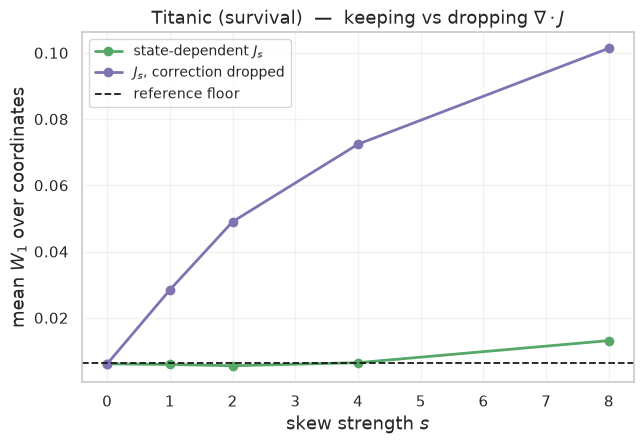

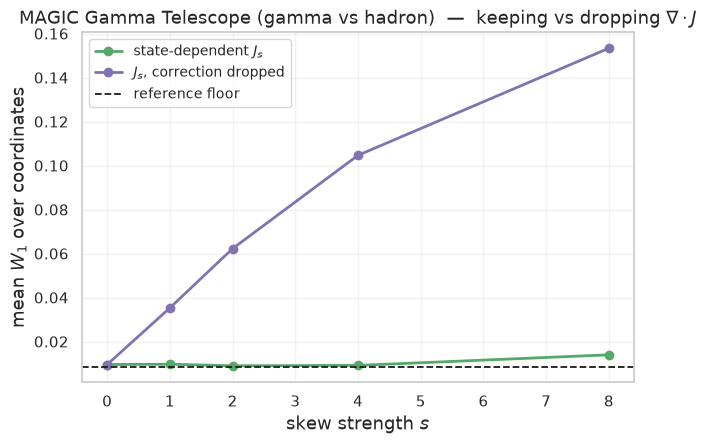

In [13]:
for key in DS:
    P.ablation_panel(ABLATION[key], REF[key]["floor"].mean(),
                     DS[key].title + r"  —  keeping vs dropping $\nabla\cdot J$",
                     "ablation_{}".format(key))
    plt.show()

## Experiment 4 — which errors vanish with the stepsize, and which do not

Two different errors live on the boundary and the same figure cannot separate them. Projection
deposits an atom on $\partial K$ that the continuous target does not have; that is a discretisation
artefact and should shrink like $\sqrt\eta$. A violated boundary condition is a bias in the
stationary law and should **not** shrink at all.

To see them apart, the horizon is held at a fixed physical time $T=\eta\,\times$ iterations, so
every row below runs the same amount of diffusion and differs only in how finely it is
discretised.

In [14]:
T_FIXED = CFG["eta"] * CFG["n_steps"]
ETAS = [CFG["eta"], CFG["eta"] / 2, CFG["eta"] / 4]
REFINE = {}
for key in DS:
    tgt, ref = REF[key]["target"], REF[key]["ref"]
    rows = []
    for eta in ETAS:
        n_steps = int(round(T_FIXED / eta))
        row = {"eta": "{:.1e}".format(eta), "iterations": n_steps}
        for kind, s in [("none", 0.0), ("const", S_MAIN), ("axial", S_MAIN)]:
            r = E.chain(key, kind, s, eta=eta, n_steps=n_steps, ref=ref)
            sc = E.score(ref, r["x"], tgt.R)
            lab = E.METHOD_LABEL[kind].replace("$", "")
            row[lab + " : W1"] = round(sc["W1_mean"], 4)
            row[lab + " : dK"] = "{:.2%}".format(sc["boundary"])
            row[lab + " : atom/sqrt(eta)"] = round(sc["boundary"] / np.sqrt(eta), 2)
        rows.append(row)
    REFINE[key] = pd.DataFrame(rows).set_index("eta")
    print("\n== {} ==  fixed physical time T = {:.2f}".format(DS[key].title, T_FIXED))
    display(REFINE[key].T)


== Titanic (survival) ==  fixed physical time T = 0.60


eta,3.0e-04,1.5e-04,7.5e-05
iterations,2000,4000,8000
J = 0 : W1,0.0061,0.006,0.0056
J = 0 : dK,6.80%,4.50%,3.10%
J = 0 : atom/sqrt(eta),3.93,3.67,3.58
constant J_a : W1,0.0387,0.0371,0.0397
constant J_a : dK,16.50%,12.45%,9.35%
constant J_a : atom/sqrt(eta),9.53,10.17,10.8
state-dependent J_s : W1,0.0065,0.0053,0.0067
state-dependent J_s : dK,7.20%,4.95%,2.80%
state-dependent J_s : atom/sqrt(eta),4.16,4.04,3.23



== MAGIC Gamma Telescope (gamma vs hadron) ==  fixed physical time T = 0.60


eta,3.0e-04,1.5e-04,7.5e-05
iterations,2000,4000,8000
J = 0 : W1,0.0096,0.0077,0.0101
J = 0 : dK,3.75%,2.50%,2.60%
J = 0 : atom/sqrt(eta),2.17,2.04,3.0
constant J_a : W1,0.0409,0.0399,0.0444
constant J_a : dK,10.30%,7.65%,7.45%
constant J_a : atom/sqrt(eta),5.95,6.25,8.6
state-dependent J_s : W1,0.0092,0.009,0.0111
state-dependent J_s : dK,3.50%,2.50%,2.55%
state-dependent J_s : atom/sqrt(eta),2.02,2.04,2.94


## Experiment 5 — does any of this reach the accuracy?

Everything so far is measured against the target distribution. A practitioner is usually
holding a decision statistic instead, so the fair question is whether a sampler this
badly biased still *classifies* badly. Three readings of the posterior, all computed on
the rows the posterior was fitted to — these are **in-sample** numbers, and the question
is whether sampling bias reaches a decision statistic, not how well the model
generalises:

* **plug-in** — accuracy of the single classifier $\bar w = \mathbb E[w]$;
* **posterior-predictive** — the majority vote, i.e. row $i$ is called correctly when
  more than half the posterior mass classifies it correctly;
* **per-draw** — the accuracy of each draw on its own, averaged. Its Monte Carlo
  standard error is the smallest of the three, so it is the one to plot.

In [15]:
ACC = {}
for key in DS:
    tgt, ref = REF[key]["target"], REF[key]["ref"]
    ref_acc = tgt.accuracy_per_draw(ref)
    sweep, dists, tab = {}, {"reference (exact target)": ref_acc}, []
    tab.append({"method": "reference (truth)", "s": "--",
                "plug-in": round(tgt.accuracy(ref), 4),
                "predictive": round(tgt.accuracy_predictive(ref), 4),
                "per-draw": round(float(ref_acc.mean()), 4),
                "per-draw sd": round(float(ref_acc.std()), 4), "mean W1": "--"})
    for kind, drop in [("const", False), ("axial", False), ("axial", True)]:
        lab = E.METHOD_LABEL["axial_nocorr" if drop else kind]
        ss, w1, am, ae = [], [], [], []
        for s in CFG["sweep"]:
            r = E.chain(key, "none" if s == 0 else kind, s, ref=ref,
                        drop_correction=drop and s > 0)
            a = tgt.accuracy_per_draw(r["x"])
            ss.append(s); w1.append(E.score(ref, r["x"], tgt.R)["W1_mean"])
            am.append(float(a.mean())); ae.append(float(a.std() / np.sqrt(len(a))))
            if s == S_MAIN:
                dists[lab] = a
                tab.append({"method": lab.replace("$", ""), "s": s,
                            "plug-in": round(tgt.accuracy(r["x"]), 4),
                            "predictive": round(tgt.accuracy_predictive(r["x"]), 4),
                            "per-draw": round(float(a.mean()), 4),
                            "per-draw sd": round(float(a.std()), 4),
                            "mean W1": round(w1[-1], 4)})
        sweep[lab] = {"s": ss, "W1_mean": w1, "acc_mean": am, "acc_se": ae}
    ACC[key] = {"sweep": sweep, "ref_acc": ref_acc, "dists": dists}
    print("\n== {} ==".format(DS[key].title))
    display(pd.DataFrame(tab).set_index("method"))


== Titanic (survival) ==


,s,plug-in,predictive,per-draw,per-draw sd,mean W1
method,,,,,,
reference (truth),--,0.7879,0.7912,0.7895,0.0088,--
constant J_a,4.0,0.7901,0.7890,0.7899,0.0090,0.0387
state-dependent J_s,4.0,0.7890,0.7879,0.7894,0.0092,0.0065
"J_s, correction dropped",4.0,0.7957,0.7924,0.7893,0.0100,0.0724



== MAGIC Gamma Telescope (gamma vs hadron) ==


,s,plug-in,predictive,per-draw,per-draw sd,mean W1
method,,,,,,
reference (truth),--,0.7960,0.7950,0.7832,0.0104,--
constant J_a,4.0,0.7935,0.7945,0.7849,0.0096,0.0409
state-dependent J_s,4.0,0.7965,0.7960,0.7833,0.0103,0.0092
"J_s, correction dropped",4.0,0.7915,0.7925,0.7853,0.0090,0.1047


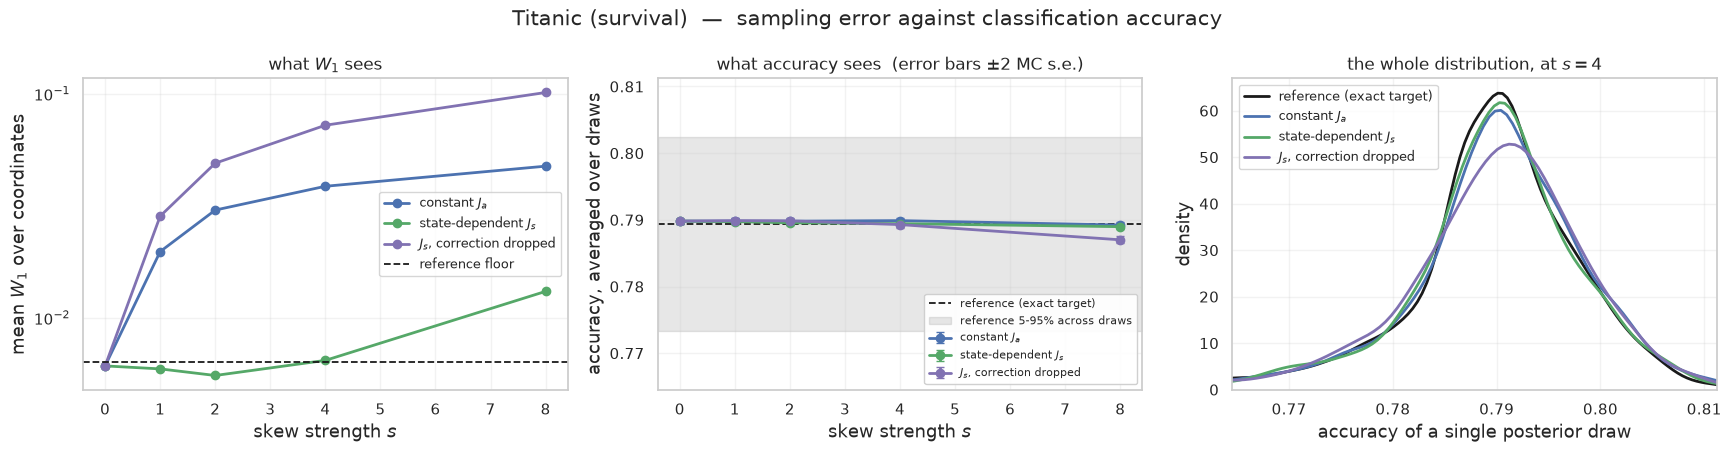

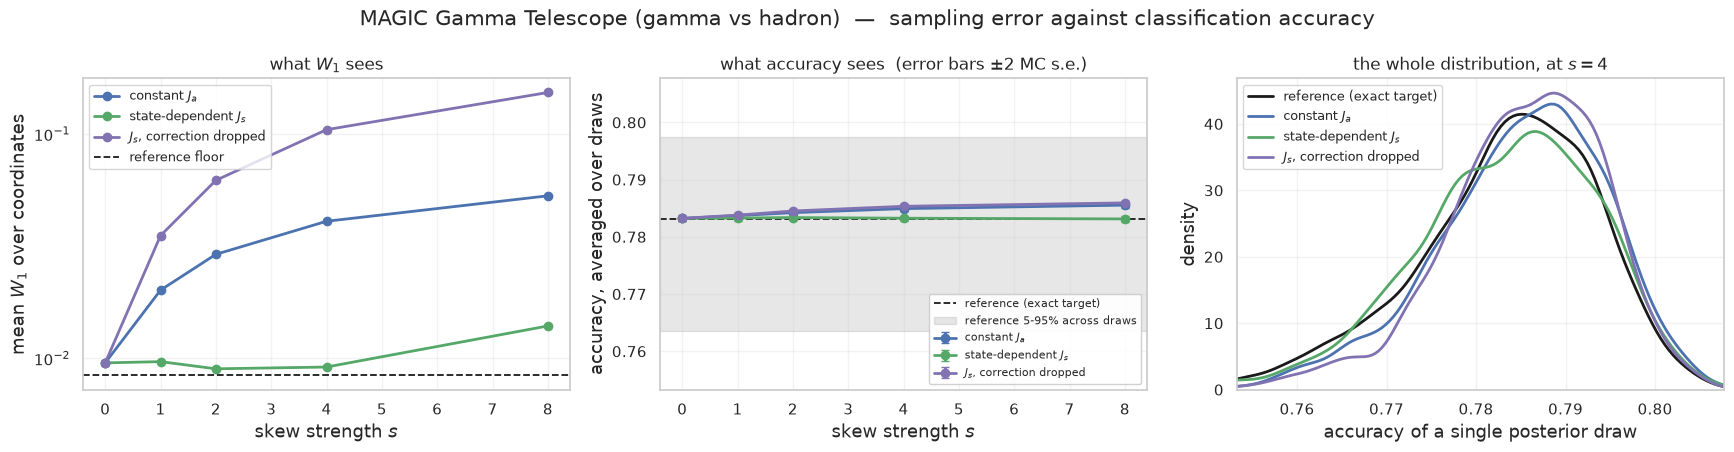

In [16]:
for key in DS:
    P.accuracy_panels(ACC[key]["sweep"], ACC[key]["ref_acc"], ACC[key]["dists"],
                      S_MAIN, REF[key]["floor"].mean(),
                      DS[key].title + "  —  sampling error against classification accuracy",
                      "accuracy_{}".format(key))
    plt.show()

### The learning curve

The tables above compare stationary distributions. A different question is how fast the
ensemble *gets* there, read through the classifier rather than through $W_1$. Every chain
starts from $w=0$, where every margin is exactly zero and accuracy is exactly chance, so
the accuracy trace is a learning curve: 0.5 up to whatever the posterior supports.

That ceiling is not 1, and it should not be. These are linear classifiers on real, noisy
data; the exact posterior itself scores 0.789 on Titanic and 0.783 on MAGIC, and a
sampler that climbed past its own target's accuracy would be reporting a bug, not a
success.

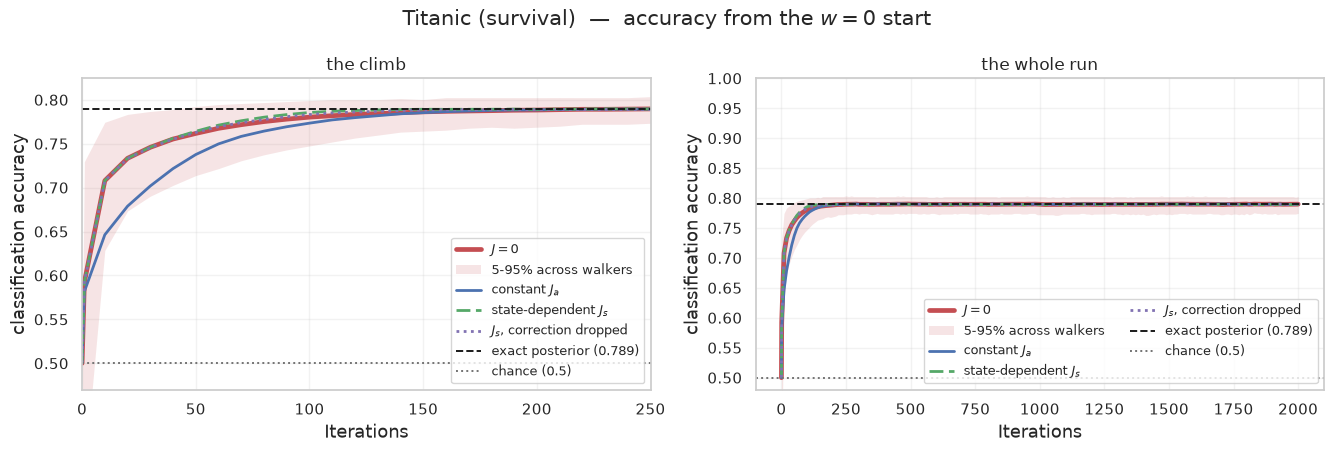


== Titanic (survival) ==  ceiling (exact posterior) 0.7895


,accuracy at start,iterations to 95% of ceiling,iterations to 99% of ceiling,final accuracy
J = 0,0.5,40.0,110.0,0.7898
constant J_a,0.5,70.0,130.0,0.7899
state-dependent J_s,0.5,40.0,90.0,0.7894
"J_s, correction dropped",0.5,40.0,100.0,0.7893


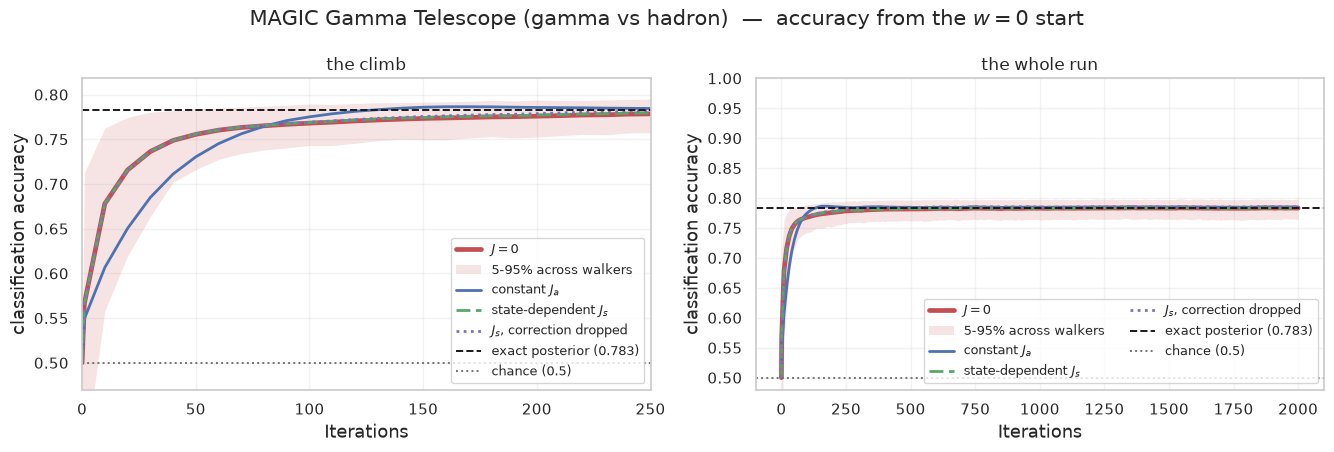


== MAGIC Gamma Telescope (gamma vs hadron) ==  ceiling (exact posterior) 0.7832


,accuracy at start,iterations to 95% of ceiling,iterations to 99% of ceiling,final accuracy
J = 0,0.5,40.0,200.0,0.7832
constant J_a,0.5,60.0,110.0,0.7849
state-dependent J_s,0.5,40.0,170.0,0.7833
"J_s, correction dropped",0.5,40.0,150.0,0.7853


In [17]:
CURVES = {}
for key in DS:
    ref_acc = REF[key]["target"].accuracy_per_draw(REF[key]["ref"])
    CURVES[key] = {}
    for kind, s, drop in [("none", 0.0, False), ("const", S_MAIN, False),
                          ("axial", S_MAIN, False), ("axial", S_MAIN, True)]:
        lab = E.METHOD_LABEL["axial_nocorr" if drop else kind]
        CURVES[key][lab] = E.learning_curve(key, kind, s, drop_correction=drop)
    P.learning_curves(CURVES[key], ref_acc,
                      DS[key].title + "  —  accuracy from the $w = 0$ start",
                      "learning_curve_{}".format(key),
                      band_for=E.METHOD_LABEL["none"])
    plt.show()

    it = CURVES[key][E.METHOD_LABEL["none"]]["iters"]
    tab = {}
    for lab, r in CURVES[key].items():
        a = r["acc"][:, 0]
        reach = [int(it[np.argmax(a >= f * ref_acc.mean())]) if (a >= f * ref_acc.mean()).any()
                 else None for f in (0.95, 0.99)]
        tab[lab.replace("$", "")] = {
            "accuracy at start": round(float(a[0]), 3),
            "iterations to 95% of ceiling": reach[0],
            "iterations to 99% of ceiling": reach[1],
            "final accuracy": round(float(a[-1]), 4)}
    print("\n== {} ==  ceiling (exact posterior) {:.4f}".format(DS[key].title, ref_acc.mean()))
    display(pd.DataFrame(tab).T)

## Summary

**Both real posteriors reproduce the synthetic notebook's headline, and the boundary condition
is what does the separating.** At $s=4$, on Titanic (floor $0.0063$, target near-boundary mass
$0.56\%$):

| method | mean $W_1$ | worst coordinate | max KS | mass near $\partial K$ |
|---|---|---|---|---|
| $J=0$ | 0.0061 | 0.0086 | 0.037 | 6.80% |
| constant $J_a$ | **0.0387** | **0.0911** | **0.218** | **16.50%** |
| state-dependent $J_s$ | 0.0065 | 0.0101 | 0.038 | 7.20% |
| reference (truth) | 0.0063 | 0.0096 | — | 0.56% |

MAGIC repeats it — $0.0096 / 0.0409 / 0.0092$ against a floor of $0.0084$, with near-boundary
mass $3.75\% / 10.30\% / 3.50\%$ against a target $0.32\%$. The constant field is antisymmetric
and divergence-free; it fails only the boundary condition, $\lVert J_a\nu\rVert\approx2.76$ on
$\partial K$, and that single defect costs a factor of six in $W_1$ and of five in KS. The
admissible state-dependent field sits at the floor while circulating.

**The correction term is not a formality once $d>3$ — this is the experiment the 3-dimensional
notebook could not run.** There $\nabla\!\cdot J_s$ was exactly zero, so the state-dependent
update coincided with the constant-$J$ one. Here it does not, and dropping it is *worse than
using an inadmissible field*:

| mean $W_1$ | $s=0$ | $s=1$ | $s=2$ | $s=4$ | $s=8$ |
|---|---|---|---|---|---|
| Titanic — $J_s$ with $\nabla\!\cdot J$ | 0.0061 | 0.0059 | 0.0055 | 0.0065 | 0.0131 |
| Titanic — $J_s$, correction dropped | 0.0061 | 0.0284 | 0.0490 | 0.0724 | **0.1014** |
| Titanic — constant $J_a$ | 0.0061 | 0.0198 | 0.0303 | 0.0387 | 0.0475 |
| MAGIC — $J_s$ with $\nabla\!\cdot J$ | 0.0096 | 0.0097 | 0.0090 | 0.0092 | 0.0140 |
| MAGIC — $J_s$, correction dropped | 0.0096 | 0.0353 | 0.0623 | 0.1047 | **0.1534** |
| MAGIC — constant $J_a$ | 0.0096 | 0.0202 | 0.0291 | 0.0409 | 0.0531 |

Even at $s=1$ — the weakest skew tested — the uncorrected field is already five times the floor.
The correction is not a small $O(s^2)$ refinement; it is a first-order term, and
$\lVert\nabla\!\cdot J_s\rVert\approx15.8$ (Titanic) and $13.0$ (MAGIC) on the wall at $s=4$, the
same order as $\lVert\nabla U_0\rVert\approx69$ and $67$.

**The two failures leave different fingerprints, and only one of them shows up at the boundary.**
Across $s=0\ldots8$ on Titanic, the uncorrected field's near-boundary mass moves
$6.80\%\to10.20\%$ while the constant field's moves $6.80\%\to27.15\%$. The uncorrected field
*is* tangential — it satisfies $J\nu=0$ exactly and passes every check in the field table — so
it puts almost nothing extra into the wall. Its damage is interior: the flux it generates is no
longer divergence-free, so it transports mass around the wrong stationary law. Boundary mass
diagnoses a violated wall condition and is blind to a missing correction term; $W_1$ against a
trusted reference catches both. Checking one is not checking the other.

**Refining the stepsize fixes the projection atom and cannot fix a wrong boundary condition.**
At fixed physical time $T=\eta\times\text{iterations}=0.6$, Titanic:

| | $\eta=3.0\times10^{-4}$ | $1.5\times10^{-4}$ | $7.5\times10^{-5}$ |
|---|---|---|---|
| $J=0$: mass near $\partial K$ | 6.80% | 4.50% | 3.10% |
| $J=0$: atom$/\sqrt\eta$ | 3.93 | 3.67 | 3.58 |
| $J=0$: $W_1$ | 0.0061 | 0.0060 | 0.0056 |
| constant $J_a$: $W_1$ | 0.0387 | 0.0371 | 0.0397 |

The atom is a discretisation artefact — it falls with $\eta$ at very nearly the predicted
$\sqrt\eta$ rate, the ratio drifting only from 3.93 to 3.58 over a 4× refinement — and the
target's own near-boundary mass is $0.56\%$, so it does vanish in the limit. The constant-$J$
$W_1$ does not move at all: $0.0387\to0.0371\to0.0397$ is a plateau, six times the floor, at
every resolution. MAGIC agrees on the plateau ($0.0409\to0.0399\to0.0444$) and on the direction
of the atom ($3.75\%\to2.50\%\to2.60\%$), but its last refinement step is inside binomial noise
(standard error $\approx0.35\%$ on 2 000 walkers), so it confirms the shrinkage without pinning
the exponent.

**On acceleration, the honest reading is modest.** On MAGIC the state-dependent field reaches
twice the floor at iteration 500 against 650 for $J=0$, and at iteration 400 its mean $W_1$ is
0.0277 against 0.0373 — roughly a quarter off the descent. On Titanic the gap is within noise
(225 against 250 iterations). At stationarity the two are indistinguishable up to $s=4$, and by
$s=8$ the extra drift starts costing discretisation accuracy on both datasets (0.0131 and
0.0140, against floors of 0.0063 and 0.0084). As in the synthetic study, the state-dependent $J$
earns its place by being the skew field that is *admissible* under the constraint, not by a
large speed-up.

**Accuracy sees none of it — so accuracy cannot be used to validate the sampler.** Across the
whole sweep, while mean $W_1$ ranges over a factor of 16 (0.0096 to 0.1534 on MAGIC), every
method's classification accuracy stays inside the reference posterior's own 5-95% spread:

| at $s=4$ | plug-in | predictive | per-draw | mean $W_1$ |
|---|---|---|---|---|
| Titanic — reference (truth) | 0.7879 | 0.7912 | 0.7895 | — |
| Titanic — constant $J_a$ | 0.7901 | 0.7890 | 0.7899 | 0.0387 |
| Titanic — state-dependent $J_s$ | 0.7890 | 0.7879 | 0.7894 | 0.0065 |
| Titanic — $J_s$, correction dropped | 0.7957 | 0.7924 | 0.7893 | 0.0724 |
| MAGIC — reference (truth) | 0.7960 | 0.7950 | 0.7832 | — |
| MAGIC — constant $J_a$ | 0.7935 | 0.7945 | 0.7849 | 0.0409 |
| MAGIC — state-dependent $J_s$ | 0.7965 | 0.7960 | 0.7833 | 0.0092 |
| MAGIC — $J_s$, correction dropped | 0.7915 | 0.7925 | 0.7853 | 0.1047 |

Worse than merely flat: on MAGIC the per-draw accuracy rises *monotonically* with the bias —
$0.7832\to0.7855$ for the constant field and $0.7832\to0.7859$ for the uncorrected one as
$s$ goes $0\to8$, both around ten Monte Carlo standard errors — while the admissible field sits
on the reference at $0.7831$. The two most badly biased samplers score **highest**. The reason
is mechanical and is asserted in the tests: $\operatorname{sign}(w^{\!\top}\psi_i)$ is invariant
under $w\mapsto cw$, so a scale-invariant statistic is structurally blind to the dominant
distortion these fields produce, which is radial — mass driven out towards the wall. Pushing
mass outward makes each draw slightly more confident and, in sample, slightly more often right.

So the three diagnostics in this notebook form a strict hierarchy, and only one of them is
safe on its own:

| | catches a violated $J\nu=0$ | catches a missing $\nabla\!\cdot J$ |
|---|---|---|
| mass near $\partial K$ | yes | **no** |
| accuracy | **no** | **no** |
| $W_1$ against a trusted reference | yes | yes |

A constrained sampler that is validated on downstream accuracy is not validated at all.

**The learning curve is the one accuracy plot that says something.** Every chain starts from
$w=0$, where every margin is exactly zero and accuracy is exactly chance, so the accuracy trace
runs 0.5 up to the posterior's own rate:

| | start | iterations to 95% of ceiling | to 99% | final |
|---|---|---|---|---|
| Titanic — $J=0$ | 0.500 | 40 | 110 | 0.7898 |
| Titanic — constant $J_a$ | 0.500 | 70 | 130 | 0.7899 |
| Titanic — state-dependent $J_s$ | 0.500 | 40 | 90 | 0.7894 |
| MAGIC — $J=0$ | 0.500 | 40 | 200 | 0.7832 |
| MAGIC — constant $J_a$ | 0.500 | 60 | 110 | 0.7849 |
| MAGIC — state-dependent $J_s$ | 0.500 | 40 | 170 | 0.7833 |

The ceiling is 0.789 and 0.783 — the exact posterior's own accuracy, not 1. These are linear
classifiers on real, noisy data, and a sampler that climbed past its own target's rate would be
reporting a bug rather than a success. Read the "iterations to 99%" column with care in exactly
one place: the constant field appears to reach MAGIC's ceiling *faster* (110 against 200) only
because it overshoots to a higher plateau (0.7849 against the target's 0.7832), so it crosses a
threshold defined by the true ceiling early. It is not converging faster; it is converging to
the wrong place and passing through the right value on the way. During the climb itself the
inadmissible field is the slowest of the three on both datasets — 0.711 against 0.749 at
iteration 40 on MAGIC — which is the only part of this figure that ranks the methods honestly.

**Two practical points that only appear on real data.**

*The anchor has to be scaled with $n$, or it stops moving.* Writing the hinge term as an average
rather than a sum keeps the smoothing gap at $O(\tau\delta)$ instead of $O(n\tau\delta)$; here
$e^{\Delta}\ge0.87$ (Titanic) and $0.92$ (MAGIC). Summing the losses would put $e^{\Delta}$ at
$e^{-n\tau\delta/2}$ — underflow, and a sampler that silently freezes.

*Without an analytic target, the floor has to be measured, not assumed.* Two independent
random-walk Metropolis references (acceptance 0.240 and 0.234) put the resolution limit at
$W_1=0.0063$ and $0.0084$. Every $J=0$ and admissible-$J_s$ number in this notebook sits at that
limit, so the honest claim is *indistinguishable from the truth at 2 000 walkers* — not
*exact*. The effects that matter here are 5 to 20 times the floor, which is why they are
readable at all.